# Machine Quality Prediction using Machine Learning

### Project Overview
This dataset simulates a realistic industrial manufacturing environment where machines produce products under
varying operational conditions. The dataset supports classification, regression, feature engineering, predictive
maintenance, and industrial analytics workflows.
Business Problem

The manufacturing company aims to:
1. Predict defective products using classification models.
2. Predict machine downtime using regression models.
3. Analyze severity of failures for maintenance prioritization.

Target Variables

defect_status: Binary classification target where 0 = Non-defective and 1 = Defective.
failure_severity: Multi-class target with No Defect, Minor, Moderate, and Critical.
downtime_minutes: Regression target estimating expected machine downtime.


### Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as exp

### Load the Dataset & Exploration

In [2]:
df = pd.read_csv("../dataset/smart_factory_synthetic_dataset_5000.csv")
df.head()

,timestamp,machine_age,operator_experience,shift,material_type,workload,maintenance_score,cooling_efficiency,temperature,vibration,pressure,humidity,power_usage,error_count,noise_level,random_sensor_1,random_sensor_2,defect_status,failure_severity,downtime_minutes
0,2024-01-01 00:00:00,9.99,3.73,Day,B,62.81,6.74,54.73,62.37,54.98,69.41,73.73,331.32,5,51.41,-0.409,-0.945,0,No Defect,82.81
1,2024-01-01 01:00:00,7.45,3.64,Day,B,54.58,NaN,57.74,53.14,50.10,61.71,73.88,290.78,3,43.32,1.061,4.731,0,No Defect,55.06
2,2024-01-01 02:00:00,10.59,0.00,Day,A,77.53,NaN,52.18,75.22,56.88,79.56,51.98,398.89,1,53.72,0.223,4.731,0,No Defect,58.74
3,2024-01-01 03:00:00,14.09,4.01,Day,B,44.40,3.48,49.64,53.84,58.20,66.22,62.35,257.91,7,47.12,1.126,2.130,0,No Defect,136.87
4,2024-01-01 04:00:00,7.06,7.20,Day,B,65.98,9.63,49.82,75.12,47.42,70.61,68.81,339.56,5,54.24,-0.061,-2.635,0,No Defect,60.08


In [3]:
df.tail()

,timestamp,machine_age,operator_experience,shift,material_type,workload,maintenance_score,cooling_efficiency,temperature,vibration,pressure,humidity,power_usage,error_count,noise_level,random_sensor_1,random_sensor_2,defect_status,failure_severity,downtime_minutes
4995,2024-07-27 03:00:00,7.80,8.90,Night,B,63.99,8.15,59.27,57.69,50.83,76.11,38.20,322.30,1,33.93,1.216,-2.707,0,No Defect,41.88
4996,2024-07-27 04:00:00,10.85,0.00,Day,C,58.80,8.00,46.68,68.32,58.97,68.96,49.07,334.65,3,57.13,-1.513,-1.455,0,No Defect,87.59
4997,2024-07-27 05:00:00,20.00,2.88,Day,A,36.19,2.14,54.90,59.26,85.90,68.42,100.00,247.46,5,71.04,0.325,3.631,1,Minor,137.53
4998,2024-07-27 06:00:00,11.23,6.49,Day,B,55.95,6.83,60.10,63.78,59.75,66.29,77.09,300.55,2,55.80,-1.287,-1.428,1,Minor,70.50
4999,2024-07-27 07:00:00,4.61,6.93,Day,C,55.81,10.00,57.14,52.23,35.92,62.36,11.91,310.08,1,31.17,-0.693,-2.859,0,No Defect,38.57


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   timestamp            5000 non-null   object 
 1   machine_age          5000 non-null   float64
 2   operator_experience  5000 non-null   float64
 3   shift                5000 non-null   object 
 4   material_type        5000 non-null   object 
 5   workload             5000 non-null   float64
 6   maintenance_score    4841 non-null   float64
 7   cooling_efficiency   5000 non-null   float64
 8   temperature          4868 non-null   float64
 9   vibration            4859 non-null   float64
 10  pressure             5000 non-null   float64
 11  humidity             4835 non-null   float64
 12  power_usage          5000 non-null   float64
 13  error_count          5000 non-null   int64  
 14  noise_level          5000 non-null   float64
 15  random_sensor_1      5000 non-null   f

In [5]:
df.shape

(5000, 20)

### Data Cleaning

In [6]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [7]:
# detecting null values
df.isnull().sum()

timestamp                0
machine_age              0
operator_experience      0
shift                    0
material_type            0
workload                 0
maintenance_score      159
cooling_efficiency       0
temperature            132
vibration              141
pressure                 0
humidity               165
power_usage              0
error_count              0
noise_level              0
random_sensor_1          0
random_sensor_2          0
defect_status            0
failure_severity         0
downtime_minutes         0
dtype: int64

#### Handling null values

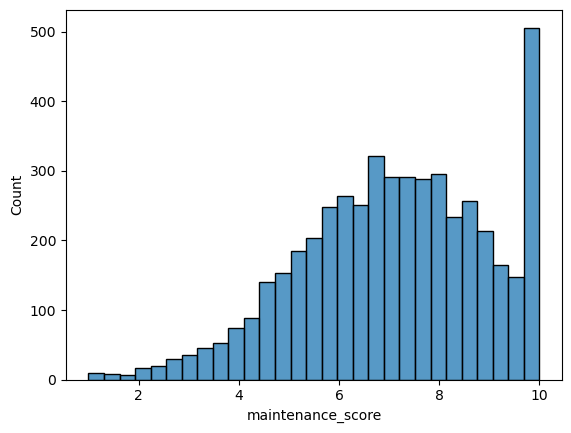

In [8]:
sns.histplot(df["maintenance_score"])
plt.show()

In [9]:
# Using median to fiil the null values because there is outliers and data is slightly left skewded
df["maintenance_score"] = df["maintenance_score"].fillna(df["maintenance_score"].median())

In [10]:
df["maintenance_score"].isnull().sum()

np.int64(0)

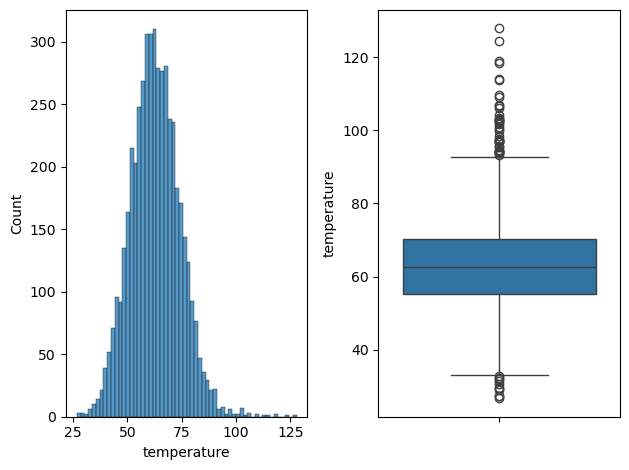

In [11]:
# 1 row, 2 columns, index 1
plt.subplot(1,2,1)
sns.histplot(df["temperature"])

# 1 row, 2 columns, index 2
plt.subplot(1,2,2)
sns.boxplot(df["temperature"])

plt.tight_layout()
plt.show()

In [12]:
# median is used because the data is slightly right skewed and has outliers
df["temperature"]=df["temperature"].fillna(df['temperature'].median())
df["temperature"].isnull().sum()

np.int64(0)

In [13]:
print(df["temperature"].dtype)

float64


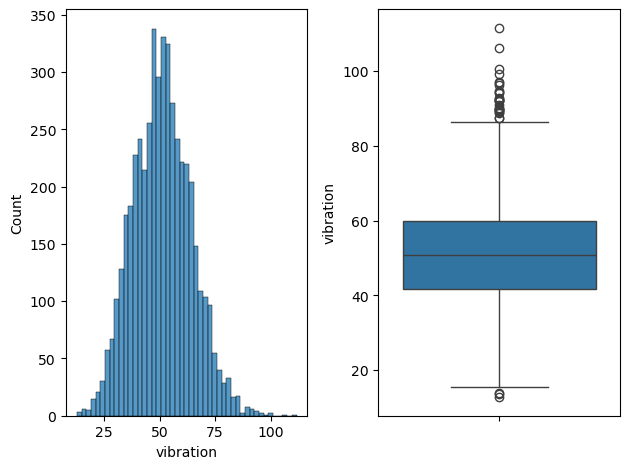

In [14]:
# 1 row, 2 columns, index 1
plt.subplot(1,2,1)
sns.histplot(df["vibration"])

# 1 row, 2 columns, index 2
plt.subplot(1,2,2)
sns.boxplot(df['vibration'])

plt.tight_layout()
plt.show()

In [15]:
df["vibration"]=df["vibration"].fillna(df["vibration"].mean())
df["vibration"].isna().sum()

np.int64(0)

In [16]:
print(df["vibration"].dtype)

float64


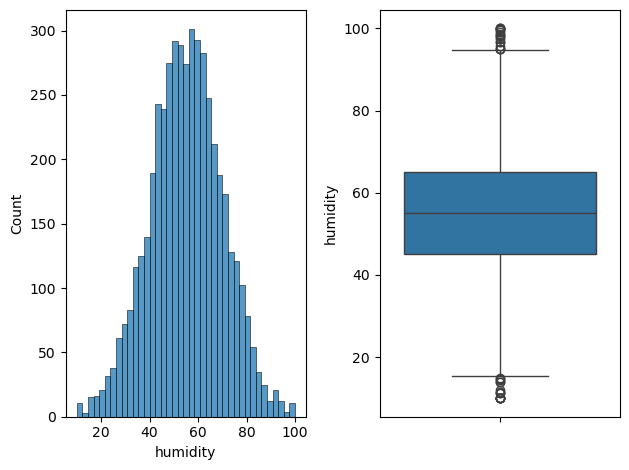

In [17]:
plt.subplot(1,2,1)
sns.histplot(df["humidity"])

plt.subplot(1,2,2)
sns.boxplot(df["humidity"])

plt.tight_layout()
plt.show()

In [18]:
df["humidity"] = df["humidity"].fillna(df["humidity"].mean())
df["humidity"].isna().sum()

np.int64(0)

In [19]:
print(df["humidity"].dtype)

float64


#### Checking Duplicate Records

In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   timestamp            5000 non-null   datetime64[ns]
 1   machine_age          5000 non-null   float64       
 2   operator_experience  5000 non-null   float64       
 3   shift                5000 non-null   object        
 4   material_type        5000 non-null   object        
 5   workload             5000 non-null   float64       
 6   maintenance_score    5000 non-null   float64       
 7   cooling_efficiency   5000 non-null   float64       
 8   temperature          5000 non-null   float64       
 9   vibration            5000 non-null   float64       
 10  pressure             5000 non-null   float64       
 11  humidity             5000 non-null   float64       
 12  power_usage          5000 non-null   float64       
 13  error_count          5000 non-nul

In [22]:
df.isnull().sum()

timestamp              0
machine_age            0
operator_experience    0
shift                  0
material_type          0
workload               0
maintenance_score      0
cooling_efficiency     0
temperature            0
vibration              0
pressure               0
humidity               0
power_usage            0
error_count            0
noise_level            0
random_sensor_1        0
random_sensor_2        0
defect_status          0
failure_severity       0
downtime_minutes       0
dtype: int64

### Statistical Summary

In [23]:
df.describe()

,timestamp,machine_age,operator_experience,workload,maintenance_score,cooling_efficiency,temperature,vibration,pressure,humidity,power_usage,error_count,noise_level,random_sensor_1,random_sensor_2,defect_status,downtime_minutes
count,5000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2024-04-14 03:30:00,8.086776,5.03229,69.833678,7.106492,53.328836,62.964530,51.222280,71.140648,55.079981,349.724410,3.408200,45.983250,-0.032122,-0.022767,0.090200,68.191318
min,2024-01-01 00:00:00,1.000000,0.00000,20.000000,1.000000,20.840000,26.710000,12.780000,47.380000,10.000000,153.200000,0.000000,20.000000,-3.602000,-4.999000,0.000000,0.000000
25%,2024-02-22 01:45:00,5.370000,2.94000,59.510000,5.890000,47.220000,55.617500,42.107500,66.340000,45.460000,315.692500,2.000000,37.197500,-0.732500,-2.494750,0.000000,41.925000
50%,2024-04-14 03:30:00,8.055000,4.95000,69.780000,7.170000,53.310000,62.685000,51.222280,71.150000,55.079981,349.435000,3.000000,45.655000,-0.020000,-0.065000,0.000000,66.270000
75%,2024-06-05 05:15:00,10.662500,7.03000,80.235000,8.510000,59.542500,70.132500,59.550000,75.962500,64.612500,383.392500,5.000000,54.587500,0.660000,2.477000,0.000000,91.602500
max,2024-07-27 07:00:00,20.000000,15.59000,120.000000,10.000000,84.440000,127.860000,111.560000,93.600000,100.000000,500.000000,13.000000,95.290000,3.307000,4.998000,1.000000,204.100000
std,NaN,3.833555,2.90277,14.987619,1.836989,9.186835,11.292973,12.935677,7.032574,14.712397,50.504503,2.192746,12.438883,0.998153,2.882959,0.286497,35.843407


In [24]:
df.columns

Index(['timestamp', 'machine_age', 'operator_experience', 'shift',
       'material_type', 'workload', 'maintenance_score', 'cooling_efficiency',
       'temperature', 'vibration', 'pressure', 'humidity', 'power_usage',
       'error_count', 'noise_level', 'random_sensor_1', 'random_sensor_2',
       'defect_status', 'failure_severity', 'downtime_minutes'],
      dtype='object')

### Exploratory Data Analysis (EDA)

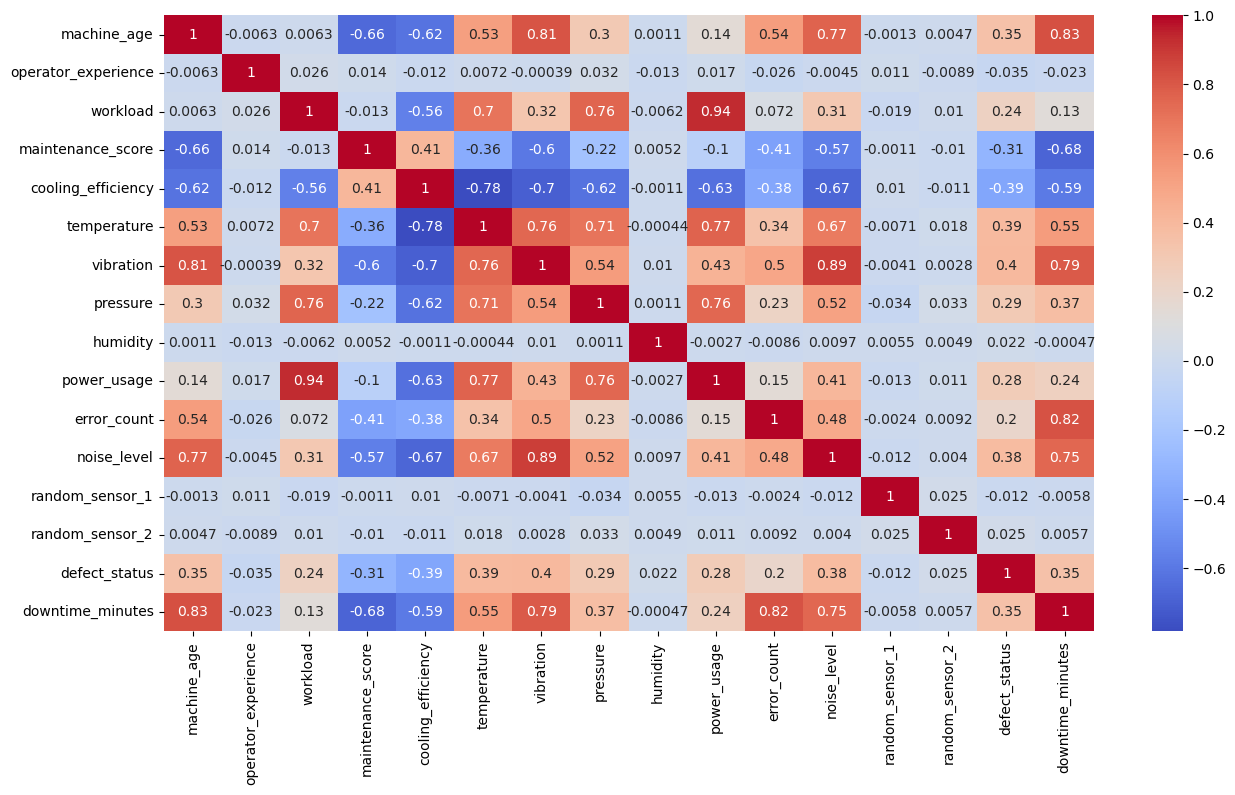

In [25]:
plt.figure(figsize=(15,8))
corr = df.corr(numeric_only = True)
sns.heatmap(corr,annot = True,cmap='coolwarm')
plt.show()

In [26]:
df["defect_status"].value_counts()

defect_status
0    4549
1     451
Name: count, dtype: int64

In [27]:
df["failure_severity"].value_counts()

failure_severity
No Defect    4549
Minor         272
Moderate      103
Critical       76
Name: count, dtype: int64

#### Detecting Outliers

In [28]:
num_cols = df.select_dtypes(include=["int64" , "float64"]).columns
num_cols

Index(['machine_age', 'operator_experience', 'workload', 'maintenance_score',
       'cooling_efficiency', 'temperature', 'vibration', 'pressure',
       'humidity', 'power_usage', 'error_count', 'noise_level',
       'random_sensor_1', 'random_sensor_2', 'defect_status',
       'downtime_minutes'],
      dtype='object')

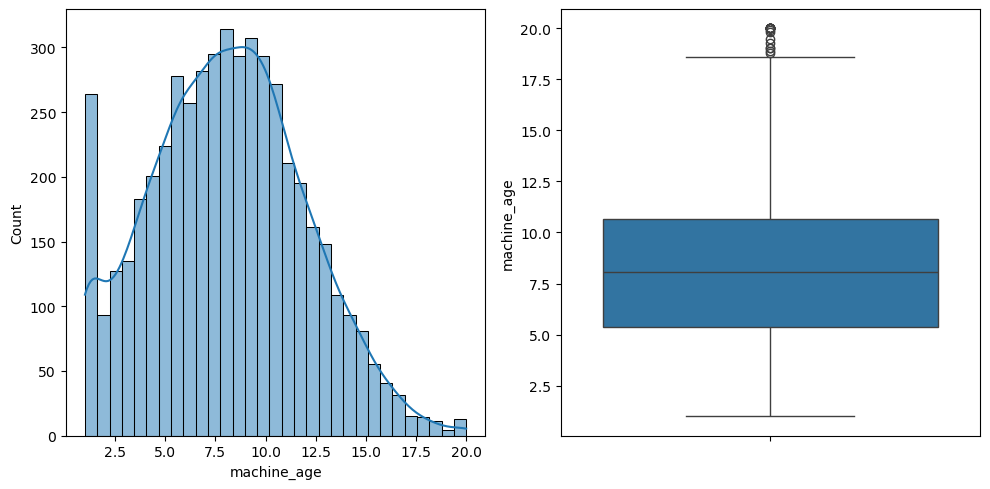

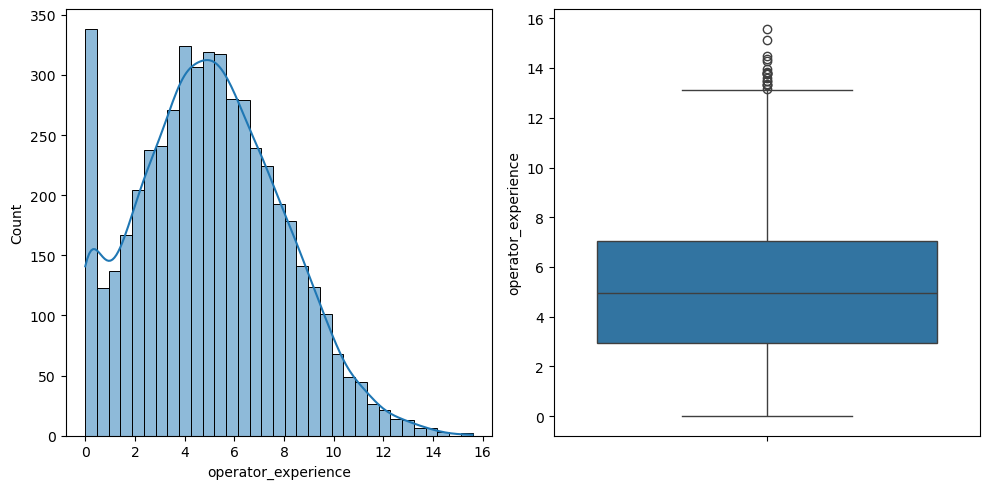

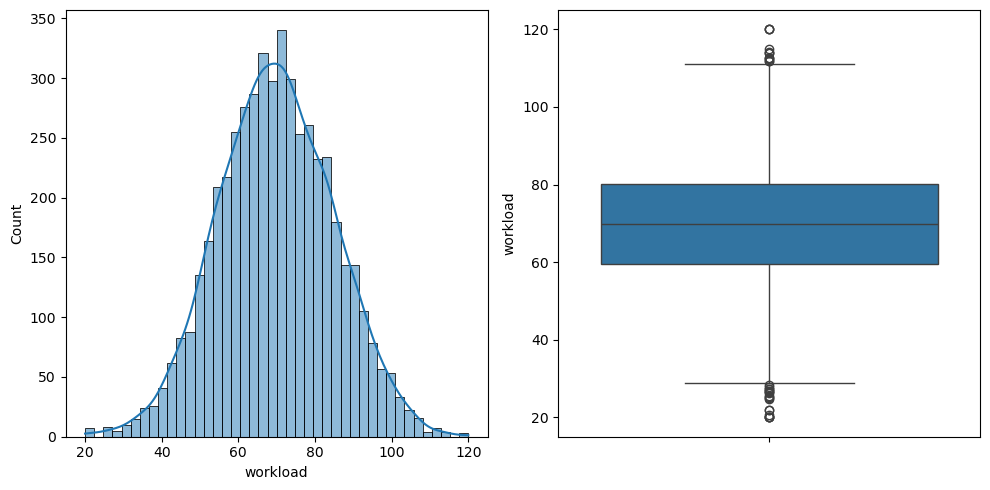

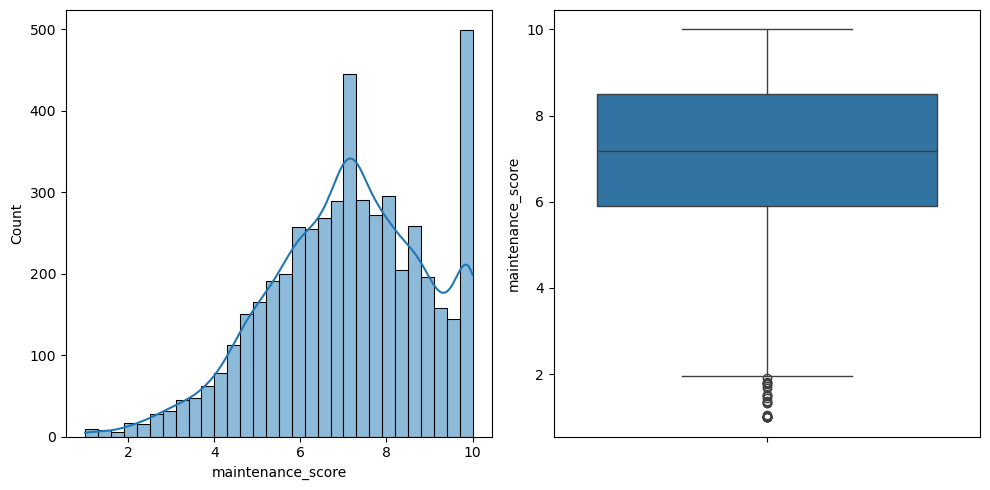

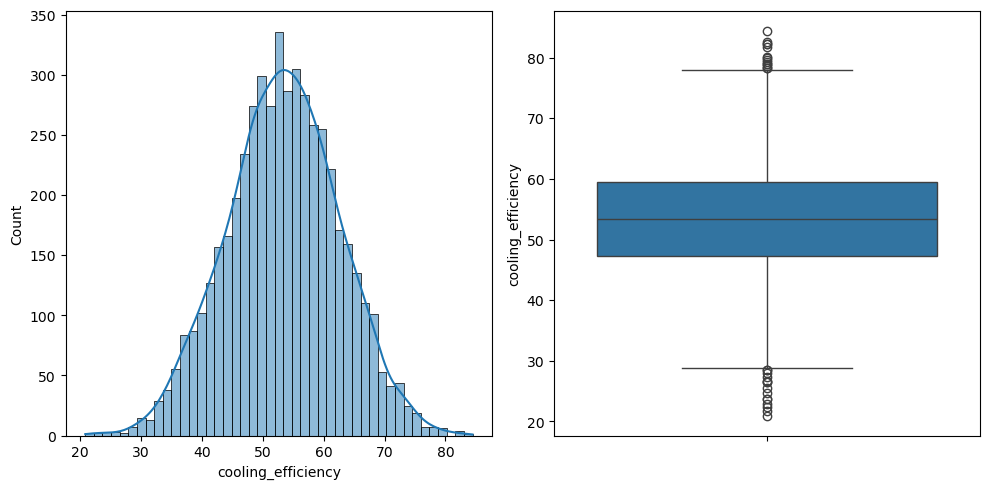

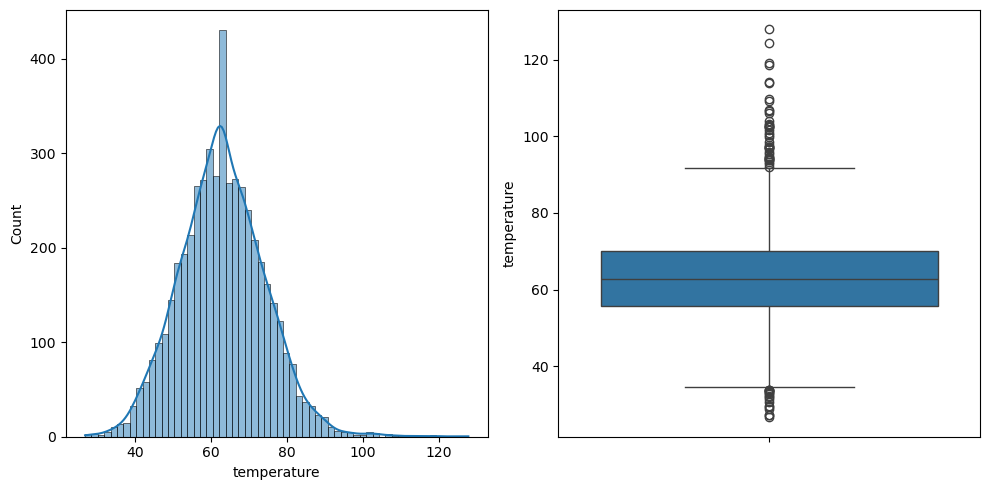

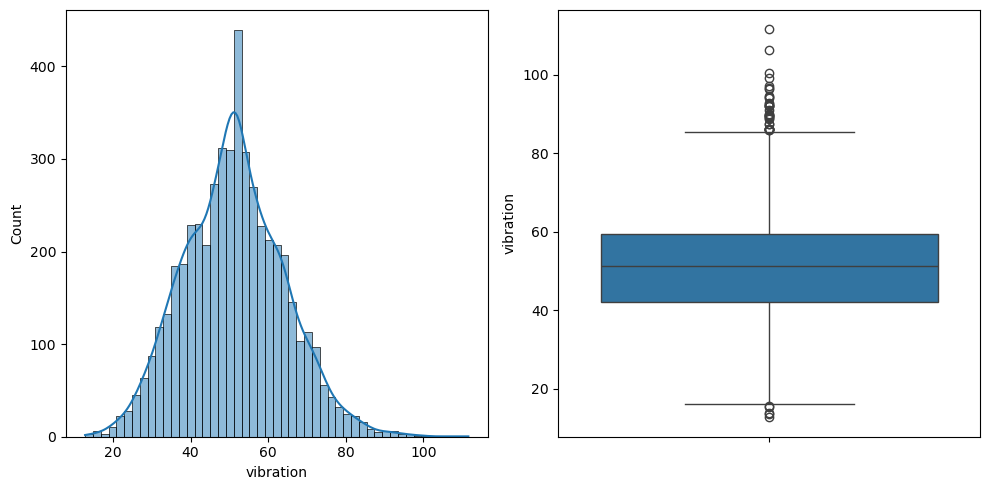

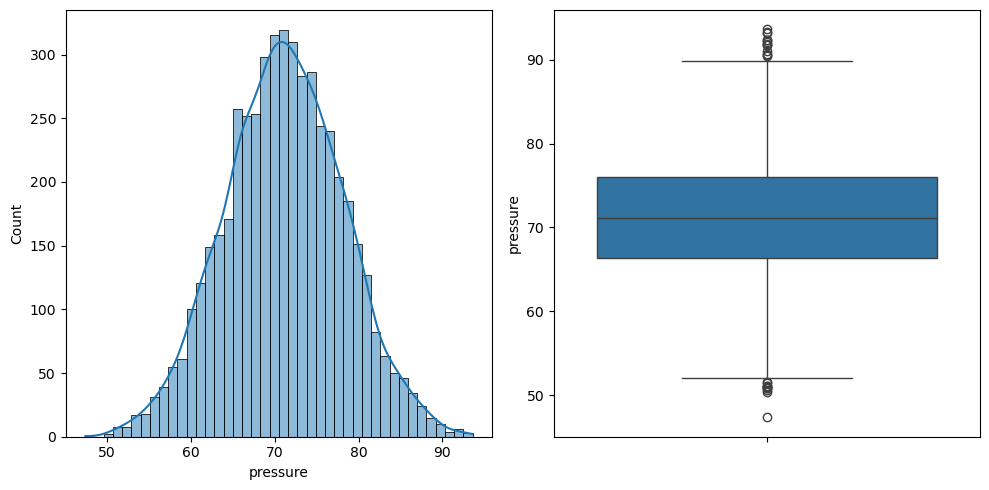

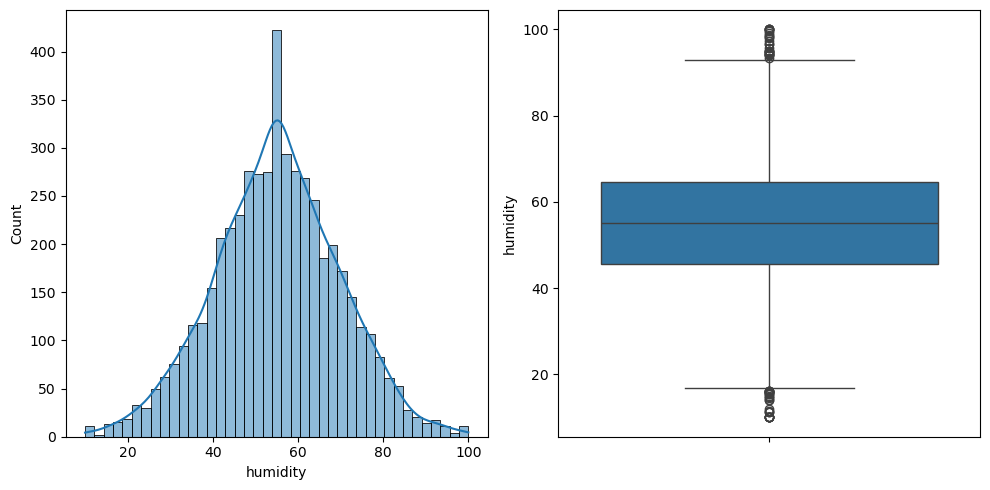

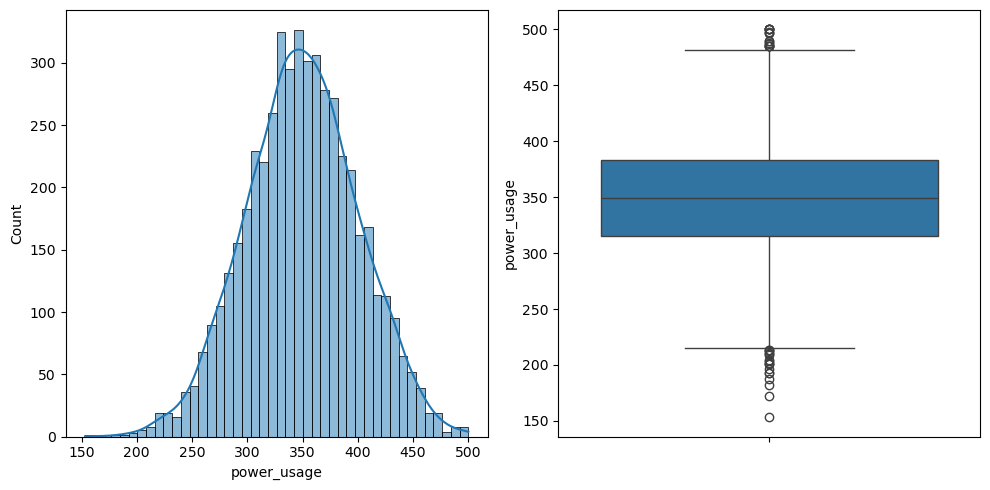

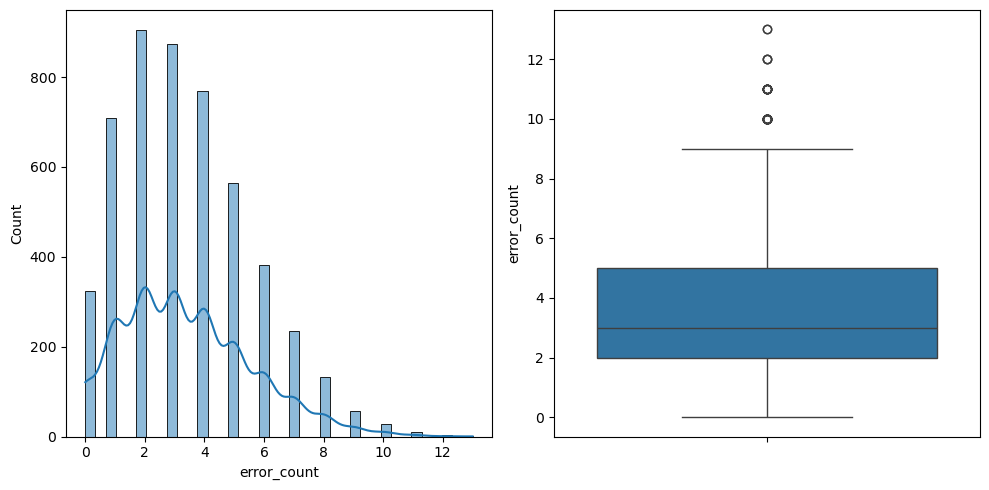

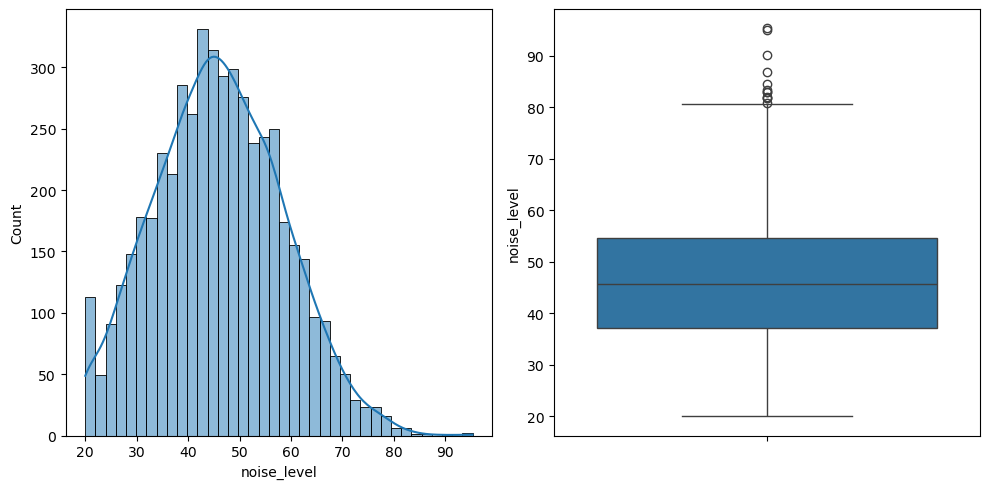

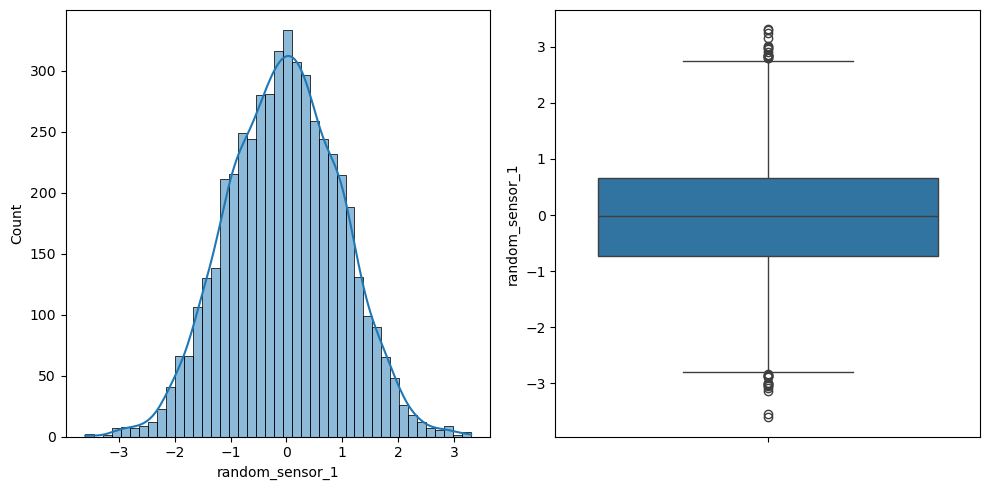

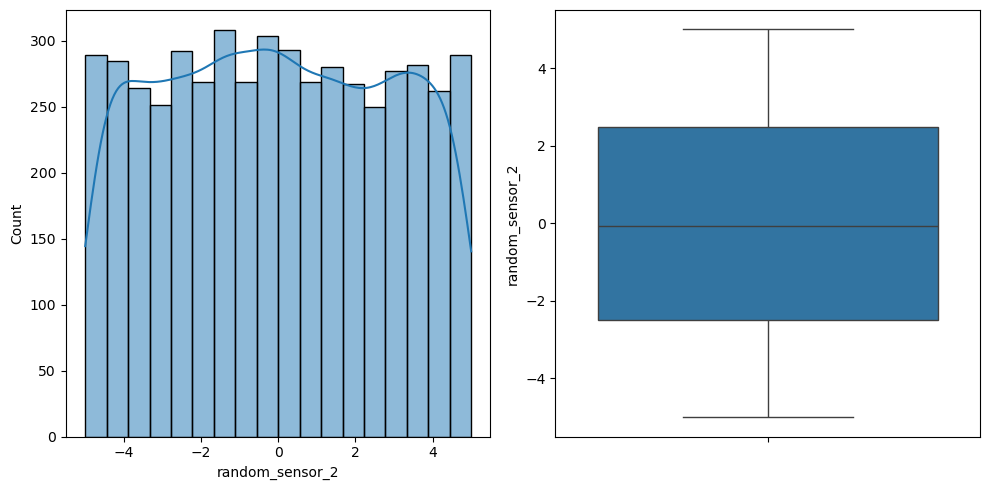

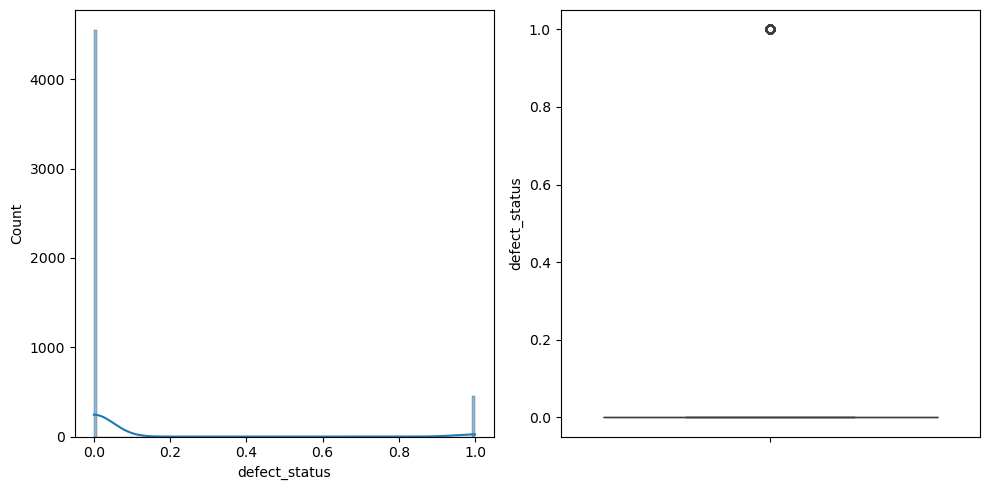

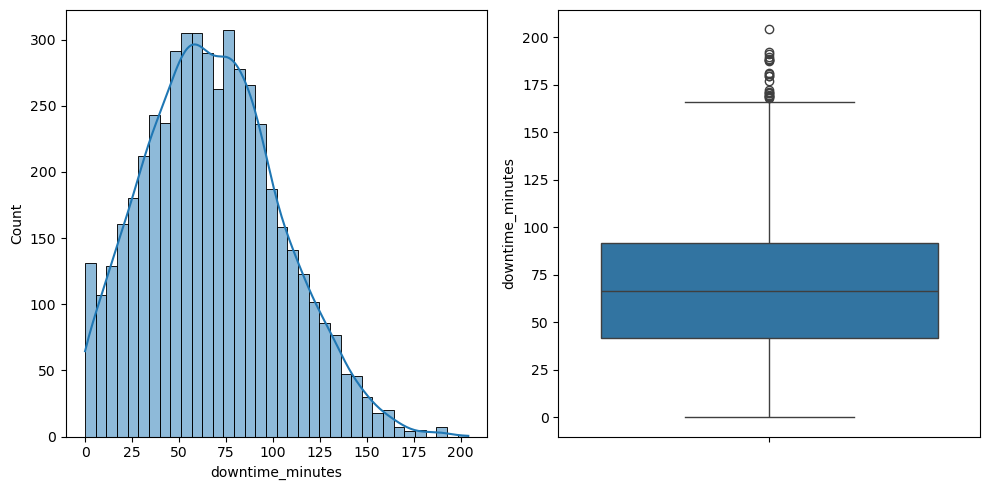

In [29]:
for col in num_cols:
    plt.figure(figsize =(10,5))

    # Histogram
    plt.subplot(1,2,1)
    sns.histplot(df[col],kde=True)

    # boxplot
    plt.subplot(1,2,2)
    sns.boxplot(df[col])

    plt.tight_layout()
    plt.show()

In [30]:
outlier_col = []
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier = df[
        (df[col] < lower) | (df[col] > upper)
        ]
    outlier_col.append(col)
    print(f"{col}:\n {outlier.shape[0]} outliers")

machine_age:
 18 outliers
operator_experience:
 18 outliers
workload:
 31 outliers
maintenance_score:
 24 outliers
cooling_efficiency:
 29 outliers
temperature:
 59 outliers
vibration:
 39 outliers
pressure:
 24 outliers
humidity:
 53 outliers
power_usage:
 34 outliers
error_count:
 45 outliers
noise_level:
 12 outliers
random_sensor_1:
 32 outliers
random_sensor_2:
 0 outliers
defect_status:
 451 outliers
downtime_minutes:
 22 outliers


In [31]:
# here the 451 outlier count of defect status is actually count of 1 , the defect status column is a binary column with values 0 and 1
# and when there is more 0 and few 1 values it counts the 1 s as outliers

In [32]:
important_cols = [
    'temperature',
    'vibration',
    'pressure',
    'workload',
    'maintenance_score',
    'power_usage',
    'machine_age',
    'error_count',
    'cooling_efficiency',
    'noise_level',
    'downtime_minutes'
]

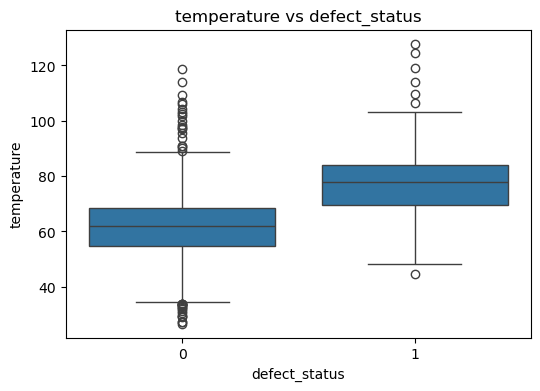

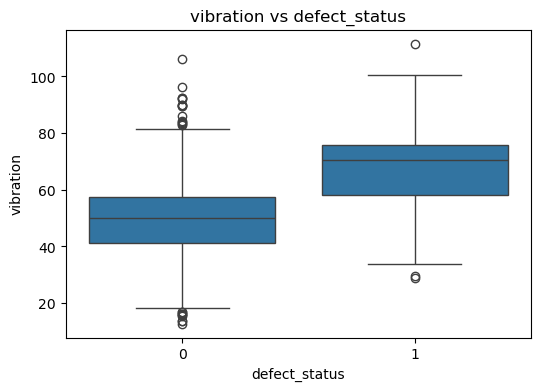

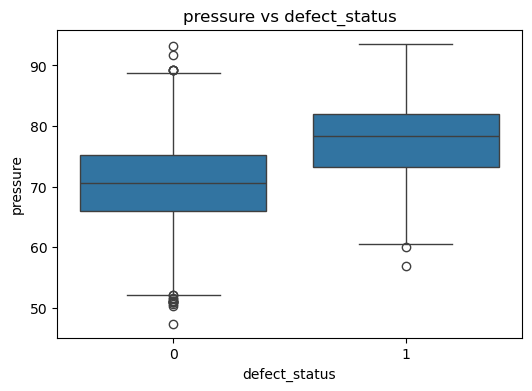

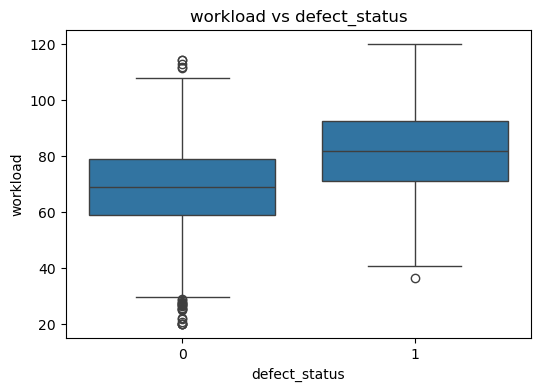

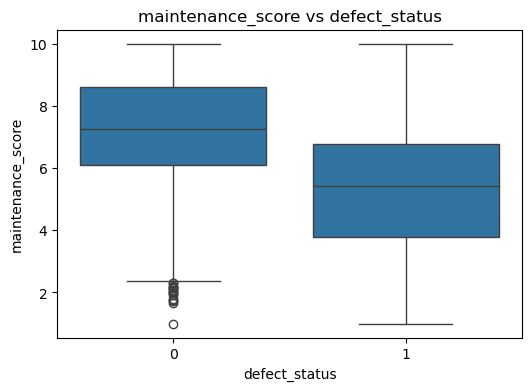

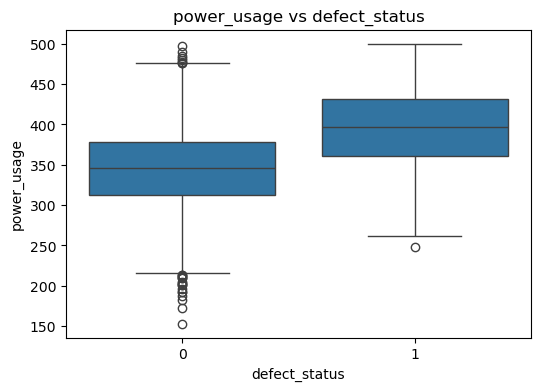

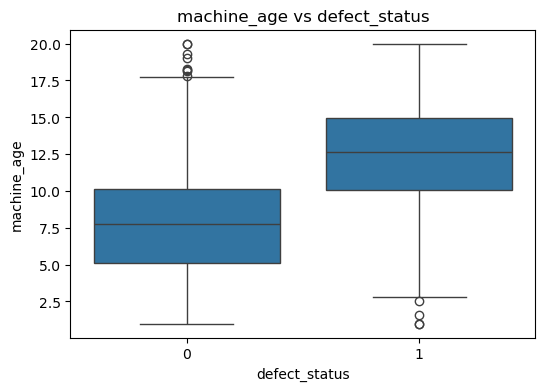

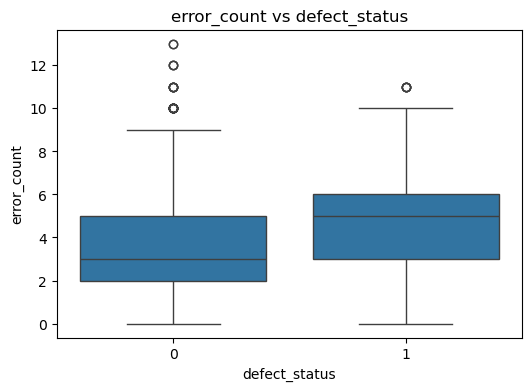

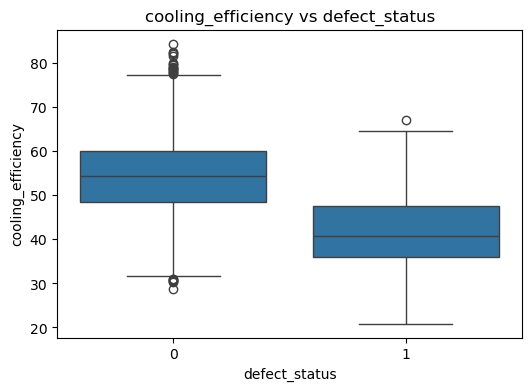

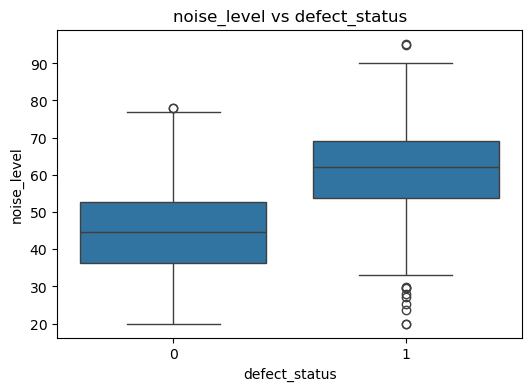

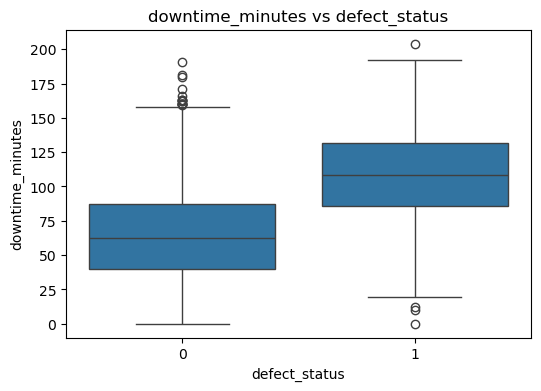

In [33]:
for col in important_cols:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        x='defect_status',
        y=col,
        data=df
    )

    plt.title(f'{col} vs defect_status')

    plt.show()

### Categorical analysis

In [34]:
df.head()

,timestamp,machine_age,operator_experience,shift,material_type,workload,maintenance_score,cooling_efficiency,temperature,vibration,pressure,humidity,power_usage,error_count,noise_level,random_sensor_1,random_sensor_2,defect_status,failure_severity,downtime_minutes
0,2024-01-01 00:00:00,9.99,3.73,Day,B,62.81,6.74,54.73,62.37,54.98,69.41,73.73,331.32,5,51.41,-0.409,-0.945,0,No Defect,82.81
1,2024-01-01 01:00:00,7.45,3.64,Day,B,54.58,7.17,57.74,53.14,50.10,61.71,73.88,290.78,3,43.32,1.061,4.731,0,No Defect,55.06
2,2024-01-01 02:00:00,10.59,0.00,Day,A,77.53,7.17,52.18,75.22,56.88,79.56,51.98,398.89,1,53.72,0.223,4.731,0,No Defect,58.74
3,2024-01-01 03:00:00,14.09,4.01,Day,B,44.40,3.48,49.64,53.84,58.20,66.22,62.35,257.91,7,47.12,1.126,2.130,0,No Defect,136.87
4,2024-01-01 04:00:00,7.06,7.20,Day,B,65.98,9.63,49.82,75.12,47.42,70.61,68.81,339.56,5,54.24,-0.061,-2.635,0,No Defect,60.08


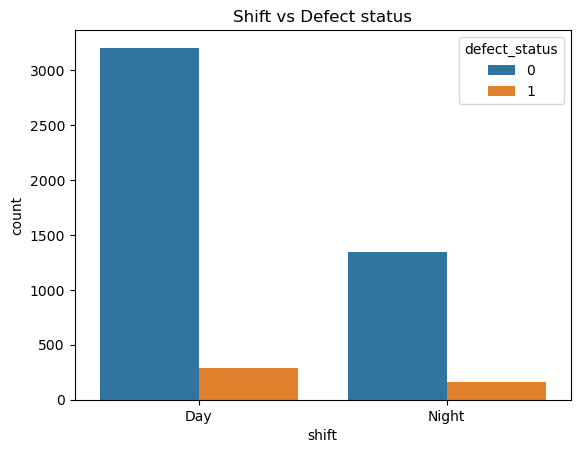

In [35]:
sns.countplot(data=df,x="shift",hue="defect_status")
plt.title("Shift vs Defect status")
plt.show()

In [36]:
# shows that Day shift has more defects compared to night shift but Day shift  has more samples 

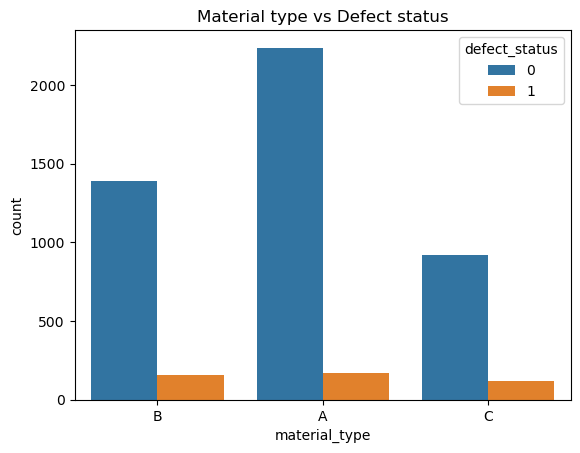

In [37]:
sns.countplot(data=df,x='material_type',hue="defect_status")
plt.title("Material type vs Defect status")
plt.show()

In [38]:
# shows the defect status between all the material is similar , but material A has more samples than Material B and C

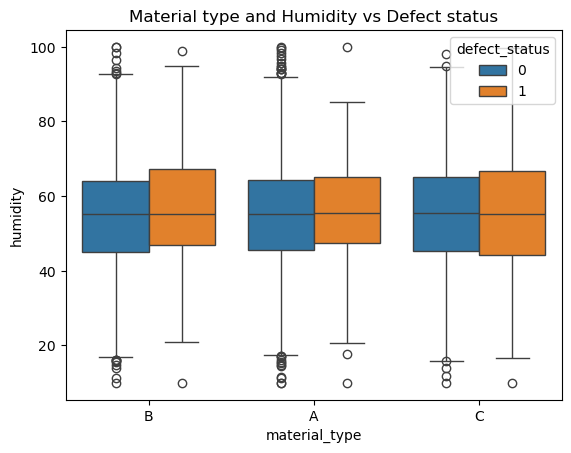

In [39]:
sns.boxplot(data=df,x="material_type",y="humidity",hue="defect_status")
plt.title("Material type and Humidity vs Defect status")
plt.show()

In [40]:
# The graph shows similar distribution of humidity between material type and defect status,
# suggesting that humidity alone doesnt affect the defect status of material

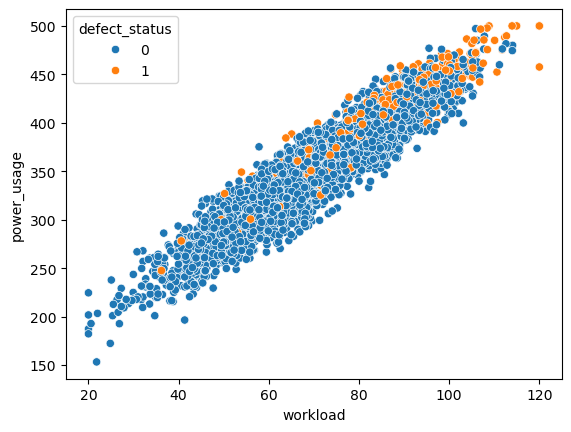

In [41]:
sns.scatterplot(data=df,x="workload",y="power_usage",hue="defect_status")
plt.show()

In [42]:
# shows a positive linear relation and we can see more number of defective status as the machines workload and power usage increases
# stress on machines can increase the defect status

### Feature Engineering

In [43]:
df["machine_risk"] = (df["machine_age"]/df["maintenance_score"])
df.head()
# older machines with low maintanance

,timestamp,machine_age,operator_experience,shift,material_type,workload,maintenance_score,cooling_efficiency,temperature,vibration,...,humidity,power_usage,error_count,noise_level,random_sensor_1,random_sensor_2,defect_status,failure_severity,downtime_minutes,machine_risk
0,2024-01-01 00:00:00,9.99,3.73,Day,B,62.81,6.74,54.73,62.37,54.98,...,73.73,331.32,5,51.41,-0.409,-0.945,0,No Defect,82.81,1.482196
1,2024-01-01 01:00:00,7.45,3.64,Day,B,54.58,7.17,57.74,53.14,50.10,...,73.88,290.78,3,43.32,1.061,4.731,0,No Defect,55.06,1.039052
2,2024-01-01 02:00:00,10.59,0.00,Day,A,77.53,7.17,52.18,75.22,56.88,...,51.98,398.89,1,53.72,0.223,4.731,0,No Defect,58.74,1.476987
3,2024-01-01 03:00:00,14.09,4.01,Day,B,44.40,3.48,49.64,53.84,58.20,...,62.35,257.91,7,47.12,1.126,2.130,0,No Defect,136.87,4.048851
4,2024-01-01 04:00:00,7.06,7.20,Day,B,65.98,9.63,49.82,75.12,47.42,...,68.81,339.56,5,54.24,-0.061,-2.635,0,No Defect,60.08,0.733126


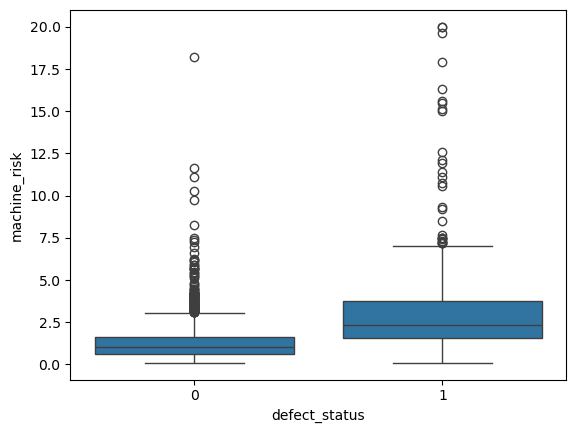

In [44]:
# to check whether the engineered feature improves class separation
sns.boxplot(x="defect_status",y="machine_risk",data=df)
plt.show()

In [45]:
# High temperature and vibration increase machine stress,
# while good cooling efficiency reduces stress.

df["machine_stress"] = (df["temperature"] * df["vibration"]/df["cooling_efficiency"])
df.head()

,timestamp,machine_age,operator_experience,shift,material_type,workload,maintenance_score,cooling_efficiency,temperature,vibration,...,power_usage,error_count,noise_level,random_sensor_1,random_sensor_2,defect_status,failure_severity,downtime_minutes,machine_risk,machine_stress
0,2024-01-01 00:00:00,9.99,3.73,Day,B,62.81,6.74,54.73,62.37,54.98,...,331.32,5,51.41,-0.409,-0.945,0,No Defect,82.81,1.482196,62.654899
1,2024-01-01 01:00:00,7.45,3.64,Day,B,54.58,7.17,57.74,53.14,50.10,...,290.78,3,43.32,1.061,4.731,0,No Defect,55.06,1.039052,46.108660
2,2024-01-01 02:00:00,10.59,0.00,Day,A,77.53,7.17,52.18,75.22,56.88,...,398.89,1,53.72,0.223,4.731,0,No Defect,58.74,1.476987,81.995278
3,2024-01-01 03:00:00,14.09,4.01,Day,B,44.40,3.48,49.64,53.84,58.20,...,257.91,7,47.12,1.126,2.130,0,No Defect,136.87,4.048851,63.124255
4,2024-01-01 04:00:00,7.06,7.20,Day,B,65.98,9.63,49.82,75.12,47.42,...,339.56,5,54.24,-0.061,-2.635,0,No Defect,60.08,0.733126,71.501212


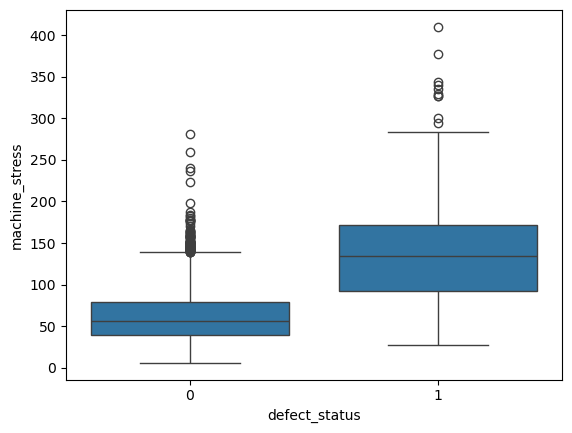

In [46]:
# Comparing machine_stress across defect classes
# to analyze whether stressed machines are more likely to fail.
sns.boxplot(x="defect_status",y="machine_stress",data=df)
plt.show()

### Data Preprocessing
##### Encoding Categorical Variables

In [47]:
# ordinal encoding
df["shift"] = df["shift"].map({'Day':0,'Night':1})

In [48]:
df = pd.get_dummies(df,columns = ['material_type'],drop_first=True)
df.head()

,timestamp,machine_age,operator_experience,shift,workload,maintenance_score,cooling_efficiency,temperature,vibration,pressure,...,noise_level,random_sensor_1,random_sensor_2,defect_status,failure_severity,downtime_minutes,machine_risk,machine_stress,material_type_B,material_type_C
0,2024-01-01 00:00:00,9.99,3.73,0,62.81,6.74,54.73,62.37,54.98,69.41,...,51.41,-0.409,-0.945,0,No Defect,82.81,1.482196,62.654899,True,False
1,2024-01-01 01:00:00,7.45,3.64,0,54.58,7.17,57.74,53.14,50.10,61.71,...,43.32,1.061,4.731,0,No Defect,55.06,1.039052,46.108660,True,False
2,2024-01-01 02:00:00,10.59,0.00,0,77.53,7.17,52.18,75.22,56.88,79.56,...,53.72,0.223,4.731,0,No Defect,58.74,1.476987,81.995278,False,False
3,2024-01-01 03:00:00,14.09,4.01,0,44.40,3.48,49.64,53.84,58.20,66.22,...,47.12,1.126,2.130,0,No Defect,136.87,4.048851,63.124255,True,False
4,2024-01-01 04:00:00,7.06,7.20,0,65.98,9.63,49.82,75.12,47.42,70.61,...,54.24,-0.061,-2.635,0,No Defect,60.08,0.733126,71.501212,True,False


#### Train Test Split

In [49]:
df.columns

Index(['timestamp', 'machine_age', 'operator_experience', 'shift', 'workload',
       'maintenance_score', 'cooling_efficiency', 'temperature', 'vibration',
       'pressure', 'humidity', 'power_usage', 'error_count', 'noise_level',
       'random_sensor_1', 'random_sensor_2', 'defect_status',
       'failure_severity', 'downtime_minutes', 'machine_risk',
       'machine_stress', 'material_type_B', 'material_type_C'],
      dtype='object')

In [50]:
X = df[['machine_age', 'operator_experience', 'shift', 'workload',
       'maintenance_score', 'cooling_efficiency', 'temperature', 'vibration',
       'pressure', 'humidity', 'power_usage', 'error_count', 'noise_level','downtime_minutes', 'machine_risk',
       'machine_stress', 'material_type_B', 'material_type_C']]
y = df['defect_status']

In [51]:
from sklearn.model_selection import train_test_split

In [52]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((4000, 18), (1000, 18), (4000,), (1000,))

#### Model Building
##### Random Forest Classification Model

In [53]:
from sklearn.ensemble import RandomForestClassifier

In [54]:
model = RandomForestClassifier(n_estimators=100,random_state=42)

In [55]:
model.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [56]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,

#### Model Accuracy

In [57]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [58]:
# accuracy score
print(f"Accuracy Score: {accuracy_score(y_pred,y_test)*100}")

Accuracy Score: 93.7


In [59]:
# confusion matrix
cm = confusion_matrix(y_pred,y_test)
print("Confusion Matrix\n")
print(cm)

Confusion Matrix

[[893  56]
 [  7  44]]


In [60]:
# classification report
cr = classification_report(y_pred,y_test)
print(cr)

              precision    recall  f1-score   support

           0       0.99      0.94      0.97       949
           1       0.44      0.86      0.58        51

    accuracy                           0.94      1000
   macro avg       0.72      0.90      0.77      1000
weighted avg       0.96      0.94      0.95      1000



In [61]:
sample = X_test.iloc[0:10]
sample

,machine_age,operator_experience,shift,workload,maintenance_score,cooling_efficiency,temperature,vibration,pressure,humidity,power_usage,error_count,noise_level,downtime_minutes,machine_risk,machine_stress,material_type_B,material_type_C
1501,5.80,1.37,0,86.90,6.98,55.89,63.18,51.83,79.76,54.110000,418.65,2,51.04,53.02,0.830946,58.590435,True,False
2586,2.72,1.88,0,100.20,8.80,44.20,74.70,55.80,72.55,55.079981,438.47,3,52.57,52.25,0.309091,94.304525,False,False
2653,12.12,6.45,1,67.88,4.18,48.86,68.87,70.60,77.28,62.590000,343.80,4,59.21,109.54,2.899522,99.513344,True,False
1055,5.31,9.50,0,75.02,10.00,52.45,55.36,51.03,77.16,72.330000,356.44,4,39.77,64.06,0.531000,53.861216,False,True
705,10.42,0.00,0,82.32,5.69,44.73,74.64,55.81,71.34,37.150000,411.90,5,41.44,93.50,1.831283,93.128960,False,True
106,15.54,1.91,0,84.69,3.93,39.63,78.24,73.70,78.09,71.650000,389.59,6,70.45,128.31,3.954198,145.503104,False,True
589,4.58,9.62,0,25.36,7.05,69.23,33.84,32.75,56.81,80.310000,200.92,2,24.25,29.26,0.649645,16.008378,False,False
2468,10.73,3.74,0,104.67,4.44,36.38,89.66,70.54,78.35,73.960000,471.35,4,63.79,98.57,2.416667,173.848719,False,False
2413,4.33,6.20,0,83.52,5.69,59.29,67.95,51.80,74.55,59.560000,384.03,0,46.54,29.39,0.760984,59.365998,True,False
1600,7.27,1.13,1,59.02,5.97,59.08,51.11,47.03,70.98,39.800000,306.76,3,30.92,64.57,1.217755,40.685567,True,False


In [62]:
y_pred2 = model.predict(sample)
sample["defect_status"] = y_pred2
sample

C:\Users\USER\AppData\Local\Temp\ipykernel_26812\3824649635.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample["defect_status"] = y_pred2


,machine_age,operator_experience,shift,workload,maintenance_score,cooling_efficiency,temperature,vibration,pressure,humidity,power_usage,error_count,noise_level,downtime_minutes,machine_risk,machine_stress,material_type_B,material_type_C,defect_status
1501,5.80,1.37,0,86.90,6.98,55.89,63.18,51.83,79.76,54.110000,418.65,2,51.04,53.02,0.830946,58.590435,True,False,0
2586,2.72,1.88,0,100.20,8.80,44.20,74.70,55.80,72.55,55.079981,438.47,3,52.57,52.25,0.309091,94.304525,False,False,0
2653,12.12,6.45,1,67.88,4.18,48.86,68.87,70.60,77.28,62.590000,343.80,4,59.21,109.54,2.899522,99.513344,True,False,0
1055,5.31,9.50,0,75.02,10.00,52.45,55.36,51.03,77.16,72.330000,356.44,4,39.77,64.06,0.531000,53.861216,False,True,0
705,10.42,0.00,0,82.32,5.69,44.73,74.64,55.81,71.34,37.150000,411.90,5,41.44,93.50,1.831283,93.128960,False,True,0
106,15.54,1.91,0,84.69,3.93,39.63,78.24,73.70,78.09,71.650000,389.59,6,70.45,128.31,3.954198,145.503104,False,True,1
589,4.58,9.62,0,25.36,7.05,69.23,33.84,32.75,56.81,80.310000,200.92,2,24.25,29.26,0.649645,16.008378,False,False,0
2468,10.73,3.74,0,104.67,4.44,36.38,89.66,70.54,78.35,73.960000,471.35,4,63.79,98.57,2.416667,173.848719,False,False,1
2413,4.33,6.20,0,83.52,5.69,59.29,67.95,51.80,74.55,59.560000,384.03,0,46.54,29.39,0.760984,59.365998,True,False,0
1600,7.27,1.13,1,59.02,5.97,59.08,51.11,47.03,70.98,39.800000,306.76,3,30.92,64.57,1.217755,40.685567,True,False,0


In [63]:
df.loc[106,'defect_status']

np.int64(1)

#### Feature Importance Analysis

In [64]:
feature_importance = pd.Series(model.feature_importances_,index = X_train.columns).sort_values(ascending=False)
feature_importance

vibration              0.134253
machine_stress         0.133702
temperature            0.099661
cooling_efficiency     0.098907
noise_level            0.064016
machine_risk           0.061818
maintenance_score      0.055538
machine_age            0.051251
power_usage            0.046157
pressure               0.045062
downtime_minutes       0.044745
workload               0.042887
operator_experience    0.042876
humidity               0.038349
error_count            0.019923
shift                  0.007741
material_type_B        0.006584
material_type_C        0.006529
dtype: float64

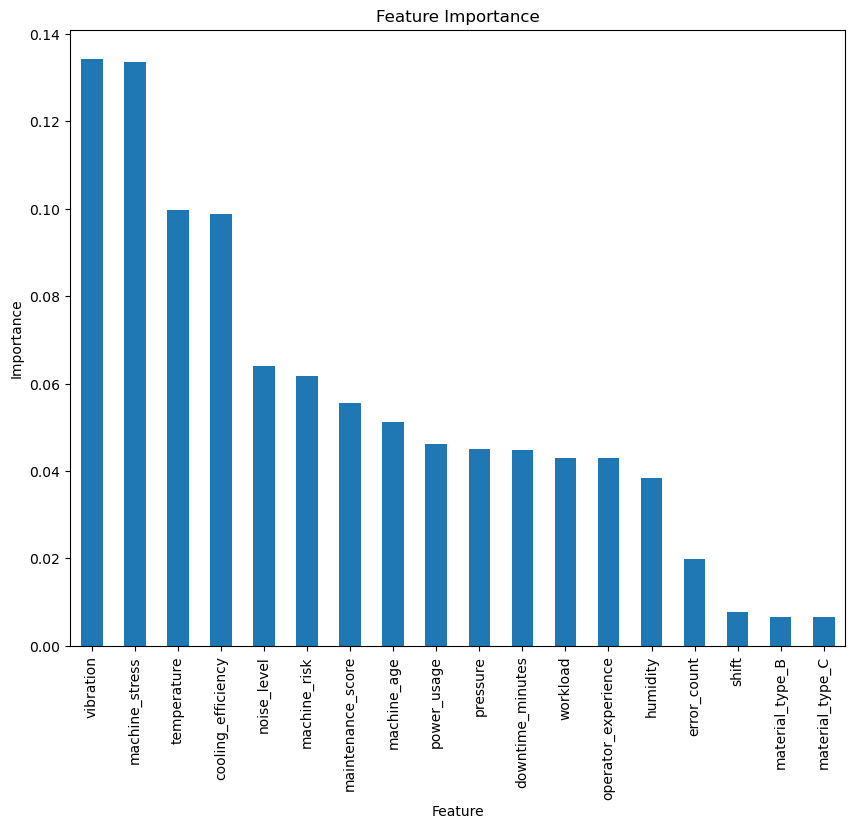

In [65]:
plt.figure(figsize=(10,8))
feature_importance.plot(kind='bar')
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.show()

### Regression
##### Random Forest Regression Model

In [66]:
df.columns

Index(['timestamp', 'machine_age', 'operator_experience', 'shift', 'workload',
       'maintenance_score', 'cooling_efficiency', 'temperature', 'vibration',
       'pressure', 'humidity', 'power_usage', 'error_count', 'noise_level',
       'random_sensor_1', 'random_sensor_2', 'defect_status',
       'failure_severity', 'downtime_minutes', 'machine_risk',
       'machine_stress', 'material_type_B', 'material_type_C'],
      dtype='object')

In [67]:
X = df[['machine_age', 'operator_experience', 'shift', 'workload',
       'maintenance_score', 'cooling_efficiency', 'temperature', 'vibration',
       'pressure', 'humidity', 'power_usage', 'error_count', 'noise_level','defect_status','machine_risk',
       'machine_stress', 'material_type_B', 'material_type_C']]
y=df['downtime_minutes']

In [68]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((4000, 18), (1000, 18), (4000,), (1000,))

In [69]:
from sklearn.ensemble import RandomForestRegressor

In [70]:
model = RandomForestRegressor(random_state=42)

In [71]:
model.fit(X_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [72]:
y_pred2 = model.predict(X_test)
y_pred2

array([ 51.0587,  45.057 , 102.8989,  53.525 ,  93.0431, 135.2579,
        34.6186,  97.0558,  39.6898,  64.5032,  70.5946,  29.7864,
        81.4869,  24.3177,  23.1549,  10.4677,  39.4984,  50.1705,
        26.7845,  82.5176,  42.9314,  98.2835,  76.2437,  32.1844,
        43.0482, 147.0041, 113.4778,  37.3582,  30.4746,  23.2947,
        94.3378, 108.7272,  67.7827,  62.1793,  93.0798,  85.2773,
        37.7978, 105.4474,  40.1971, 114.8706,  78.7464,  46.6488,
        85.6253, 106.8974, 120.9988, 102.4154,  57.2879,  26.3388,
        77.2645,  81.9016,  72.2244, 117.318 ,  48.0738,  34.7588,
        53.5535,  72.0032,  57.9012,  52.8777,  51.8593,  63.6498,
         8.1746,  39.163 , 126.4691,  89.782 ,  23.9017,  85.3006,
       116.8167,  56.2537,  85.0527,  56.1132,  36.2529,  24.5242,
        47.9894, 107.6013,  87.8556,  34.5153, 103.2609, 141.1927,
       103.5944,  75.123 ,  17.2325,  61.6108,  59.0287, 147.516 ,
        15.8707, 119.4661,  56.6432,  62.3658,  15.6854,  24.4

#### model accuracy

In [73]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [74]:
mae = mean_absolute_error(y_pred2,y_test)
mse = mean_squared_error(y_pred2,y_test)
r2 = r2_score(y_pred2,y_test)
rmse = np.sqrt(mse)

In [75]:
print(f"MAE = {mae}")
print(f"MSE = {mse}")
print(f"RMSE = {rmse}")
print(f"R2 score = {r2}")

MAE = 8.434655
MSE = 115.10453919661997
RMSE = 10.728678352743174
R2 score = 0.9017899119911769


In [76]:
# predictions are off by about 8.4 downtime minutes

In [77]:
# feature importance
feature_importance2 = pd.Series(model.feature_importances_,index = X_train.columns).sort_values(ascending=False)
feature_importance2

machine_risk           0.554771
error_count            0.296799
vibration              0.041557
machine_age            0.040199
noise_level            0.011641
maintenance_score      0.007960
humidity               0.006866
operator_experience    0.006428
pressure               0.005939
machine_stress         0.005851
cooling_efficiency     0.005750
temperature            0.005005
power_usage            0.004452
workload               0.004167
shift                  0.000773
material_type_B        0.000769
material_type_C        0.000634
defect_status          0.000438
dtype: float64

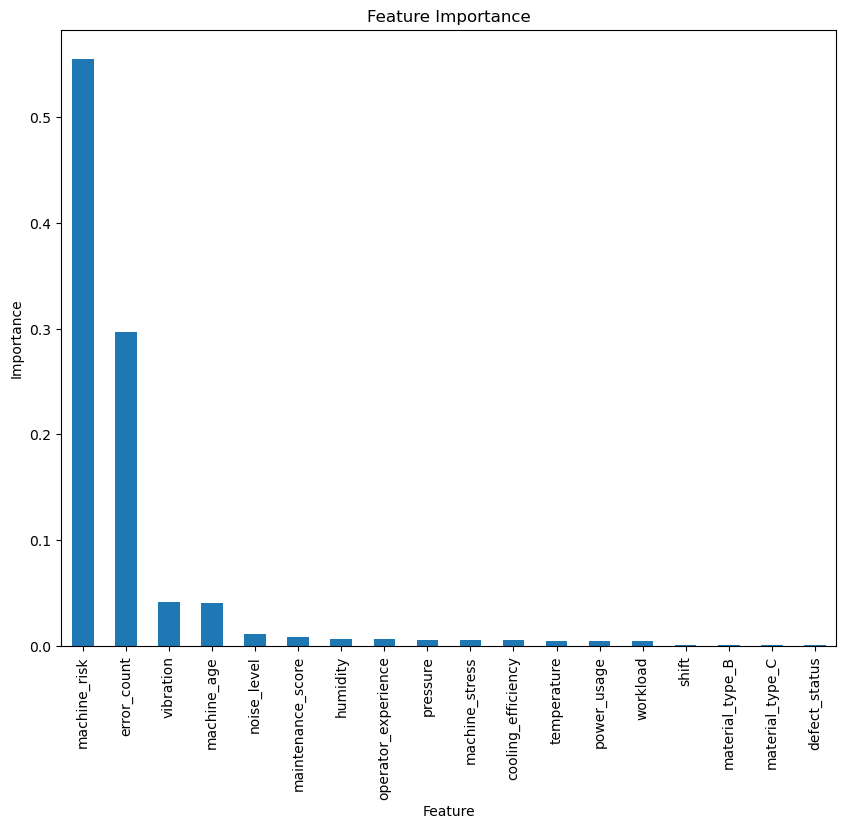

In [78]:
plt.figure(figsize=(10,8))
feature_importance2.plot(kind='bar')
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.show()

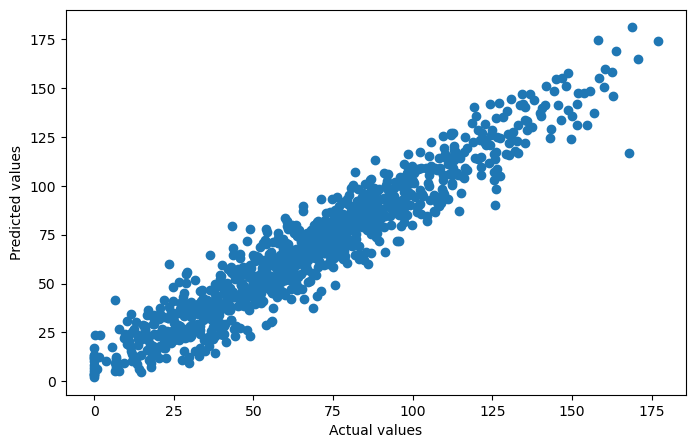

In [79]:
plt.figure(figsize=(8,5))
plt.scatter(y_test,y_pred2)
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.show()

In [80]:
# Conclusion

# The Random Forest models successfully predicted machine quality and estimated downtime using manufacturing sensor data.


# - Missing values were handled using statistical imputation.
# - Feature engineering improved representation of machine condition.
# - Random Forest performed well for classification.
# - Feature importance identified the most influential manufacturing parameters.
# - The project demonstrates a complete machine learning workflow from raw data to prediction.